In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import torch
import numpy as np
import pandas as pd

from flonacomldft.utils.io_utils import (load_pickle_file,
    get_project_path,
    load_csv_file
)

from flonacomldft.models.mlp import MLP
from flonacomldft.train_mlp_from_data import train_mlp

import matplotlib.pyplot as plt

In [3]:
path_from_adaptive = "/2-adaptive-mlp"
adaptive_to_load = lambda isomer, idx: "results_adaptive_is{:d}_{:d}/adaptive_sampling_is{:d}_{:d}.pkl".format(
        isomer, 
        idx, 
        isomer, 
        idx)

datasets = load_pickle_file(adaptive_to_load(0, 31959910), 
        path = get_project_path() + path_from_adaptive
        )['mlps_datasets']

In [4]:
datasets['train'] = datasets['train'][0]
datasets['test'] = datasets['test'][0]

In [5]:
for key in datasets.keys():
    print("{:s}: ".format(key), datasets[key].shape)

train:  torch.Size([12900, 14])
test:  torch.Size([3600, 14])


In [6]:
dim = 12
n_hidden = 128
n_layers = 4
n_iter = 75000
lr = 1e-4
bs = 500
use_scheduler = True
step_scheduler = 5000
with_tqdm = False

model = MLP([dim] +  [n_hidden] * n_layers + [1])

In [51]:
mlp_dic = train_mlp(model, 
                datasets['train'], 
                datasets['test'], 
                n_iter = n_iter,
                lr = lr,
                bs = bs,
                use_scheduler = use_scheduler,
                step_scheduler = step_scheduler,
                with_tqdm = False,
                dim = dim) 

Number of epochs:  2907
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 1.00e-04 	 4.36e+01 	 1.56e+02 	 1.7e+01
2.9e+02 	 1.00e-04 	 5.28e-03 	 2.46e-02 	 1.7e+01
5.8e+02 	 1.00e-04 	 1.50e-03 	 1.03e-02 	 1.7e+01
8.7e+02 	 1.00e-04 	 8.65e-04 	 7.03e-03 	 1.7e+01
1.2e+03 	 1.00e-04 	 6.59e-04 	 6.48e-03 	 1.7e+01
1.4e+03 	 1.00e-04 	 5.26e-04 	 5.95e-03 	 1.7e+01


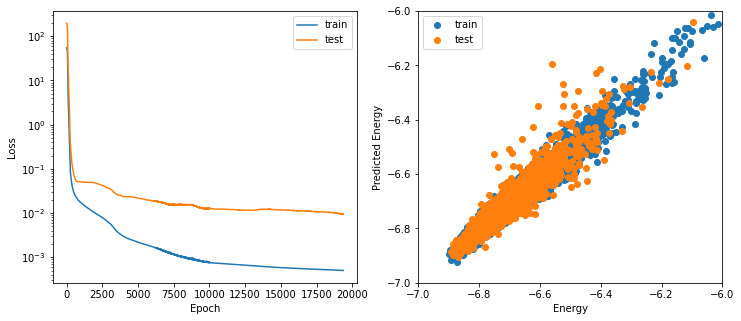

In [49]:
predictions = {}
predictions['train'] = model(datasets['train'][:, :12])
predictions['test'] = model(datasets['test'][:, :12])

fig, ax = plt.subplots(1, 2, figsize = (12, 5))

ax[0].plot(mlp_dic['avg_train_losses'], label = 'train')
ax[0].plot(mlp_dic['avg_test_losses'], label = 'test')
ax[0].legend()
ax[0].set_yscale('log')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')

ax[1].scatter(datasets['train'][:, 12].detach().numpy(),
            predictions['train'].detach().numpy(),
            label = 'train')
ax[1].scatter(datasets['test'][:, 12].detach().numpy(),
            predictions['test'].detach().numpy(),
            label = 'test')
ax[1].legend()
ax[1].set_xlabel('Energy')
ax[1].set_ylabel('Predicted Energy')

ax[1].set_xlim(-7, -6)
ax[1].set_ylim(-7, -6)

plt.show()

In [9]:
#all_losses = {}
#all_losses['train'] = []
#all_losses['test'] = []
#
#for mlp_dic in models:
#    all_losses['train'].append(mlp_dic['avg_train_losses'])
#    all_losses['test'].append(mlp_dic['avg_test_losses'])
#
##flatten the list
#all_losses['train'] = [item for sublist in all_losses['train'] for item in sublist]
#all_losses['test'] = [item for sublist in all_losses['test'] for item in sublist]
#
#fig, ax = plt.subplots(1, 1, figsize = (10, 5))
#ax.plot(all_losses['train'], label = 'train')
#ax.plot(all_losses['test'], label = 'test')
#ax.legend()
#ax.set_yscale('log')
#ax.set_xlabel('Epoch')
#ax.set_ylabel('Loss')

In [14]:
def run_training(isomer, 
        idx,
        hyperparams,
        init_n_samples,
        final_n_samples,
        step_n_samples,
        skip,
        ):

        datasets = load_pickle_file(adaptive_to_load(isomer, idx), 
                path = get_project_path() + path_from_adaptive
                )['mlps_datasets']

        datasets['train'] = datasets['train'][0]
        datasets['test'] = datasets['test'][0]

        old_losses = {} 
        old_losses['train'] = [load_pickle_file(adaptive_to_load(isomer, idx),
                path = get_project_path() + path_from_adaptive
                )['dict_mlps'][i][0]['avg_train_losses'] for i in range(51)]
        old_losses['test'] = [load_pickle_file(adaptive_to_load(isomer, idx),
                path = get_project_path() + path_from_adaptive
                )['dict_mlps'][i][0]['avg_test_losses'] for i in range(51)]
        
        old_losses['train'] = [item for sublist in old_losses['train'] for item in sublist]
        old_losses['test'] = [item for sublist in old_losses['test'] for item in sublist]
        
        dim = hyperparams['dim']
        n_hidden = hyperparams['n_hidden']
        n_layers = hyperparams['n_layers']
        n_iter = hyperparams['n_iter']
        lr = hyperparams['lr']
        bs = hyperparams['bs']
        use_scheduler = hyperparams['use_scheduler']
        step_scheduler = hyperparams['step_scheduler']
        with_tqdm = hyperparams['with_tqdm']

        model = MLP([dim] +  [n_hidden] * n_layers + [1])

        models = []

        #for N_samples in np.array([1000]+list(range(2800, 16000, 300)))[:5]:
        for i, N_samples in enumerate(np.arange(init_n_samples, final_n_samples, step_n_samples)[::skip][:]):

            print("N_samples: ", N_samples)
            print("N_samples*0.8: ", int(N_samples*0.8))
            print("N_samples*0.2: ", int(N_samples*0.2))
            print('N iterations: ', n_iter)
            print('Batch size: ', bs)
            print('Learning rate: ', lr)

            final = {'train': int(N_samples*0.8), 'test': int(N_samples*0.2)}

            mlp_dic = train_mlp(model, 
                            datasets['train'][:final['train']], 
                            datasets['test'][:final['test']], 
                            n_iter = n_iter,
                            lr = lr,
                            bs = bs,
                            use_scheduler = use_scheduler,
                            step_scheduler = step_scheduler,
                            with_tqdm = False,
                            dim = dim)

            models.append(mlp_dic)

            model = mlp_dic['model']

            predictions = {}
            predictions['train'] = model(datasets['train'][:final['test'], :12])
            predictions['test'] = model(datasets['test'][:final['test'], :12])

            fig, ax = plt.subplots(1, 2, figsize = (12, 5))

            ax[0].plot(mlp_dic['avg_train_losses'], label = 'train')
            ax[0].plot(mlp_dic['avg_test_losses'], label = 'test')
            ax[0].legend()
            ax[0].set_yscale('log')
            ax[0].set_xlabel('Epoch')
            ax[0].set_ylabel('Loss')

            ax[1].scatter(datasets['train'][:final['test'], 12].detach().numpy(),
                        predictions['train'].detach().numpy(),
                        label = 'train')
            ax[1].scatter(datasets['test'][:final['test'], 12].detach().numpy(),
                        predictions['test'].detach().numpy(),
                        label = 'test')
            ax[1].legend()
            ax[1].set_xlabel('Energy')
            ax[1].set_ylabel('Predicted Energy')
            
            fig.suptitle('Isomer {:d}, Cycle {:d}'.format(isomer, i*skip-1))

            #ax[1].set_xlim(-7, -6)
            #ax[1].set_ylim(-7, -6)

            plt.show()

            n_iter = n_iter + 3000*i
            #n_iter = int(n_iter/2) + 3000*i

        all_losses = {}
        all_losses['train'] = []
        all_losses['test'] = []
        
        for mlp_dic in models:
            all_losses['train'].append(mlp_dic['avg_train_losses'])
            all_losses['test'].append(mlp_dic['avg_test_losses'])
        
        #flatten the list
        all_losses['train'] = [item for sublist in all_losses['train'] for item in sublist]
        all_losses['test'] = [item for sublist in all_losses['test'] for item in sublist]
        
        fig, ax = plt.subplots(1, 1, figsize = (10, 5))
        ax.plot(all_losses['train'], label = 'train')
        ax.plot(all_losses['test'], label = 'test')
        ax.plot(old_losses['train'], label = 'old train', linestyle = '--')
        ax.plot(old_losses['test'], label = 'old test', linestyle = '--')
        ax.legend()
        ax.set_yscale('log')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')

        fig.suptitle('Isomer {:d}, MLP training stages'.format(isomer, i*skip-1))

        return models, all_losses   

        

N_samples:  1000
N_samples*0.8:  800
N_samples*0.2:  200
N iterations:  5000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  5000
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 5.85e+01 	 2.34e+02 	 1.7e+01
5.0e+02 	 5.00e-05 	 9.95e+00 	 3.99e+01 	 3.3e+01
1.0e+03 	 5.00e-05 	 5.94e-01 	 1.67e+00 	 2.7e+00
1.5e+03 	 5.00e-05 	 8.83e-02 	 2.93e-01 	 4.3e-01
2.0e+03 	 5.00e-05 	 3.51e-02 	 1.57e-01 	 1.6e-01
2.5e+03 	 5.00e-05 	 2.02e-02 	 9.71e-02 	 8.1e-02
3.0e+03 	 5.00e-05 	 1.42e-02 	 7.05e-02 	 4.7e-02
3.5e+03 	 5.00e-05 	 1.09e-02 	 5.56e-02 	 3.2e-02
4.0e+03 	 5.00e-05 	 8.80e-03 	 4.57e-02 	 2.0e-02
4.5e+03 	 5.00e-05 	 7.24e-03 	 3.96e-02 	 1.6e-02


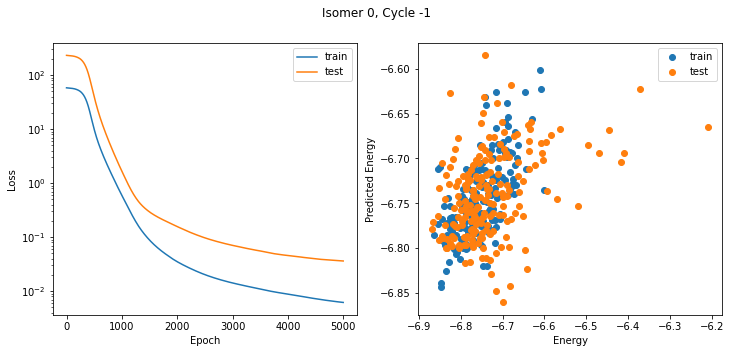

N_samples:  2500
N_samples*0.8:  2000
N_samples*0.2:  500
N iterations:  5000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  2500
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 1.71e-02 	 4.36e-02 	 1.8e-01
2.5e+02 	 5.00e-05 	 1.29e-02 	 3.86e-02 	 3.8e-02
5.0e+02 	 5.00e-05 	 1.18e-02 	 3.39e-02 	 2.7e-02
7.5e+02 	 5.00e-05 	 1.08e-02 	 3.15e-02 	 2.0e-02
1.0e+03 	 5.00e-05 	 9.83e-03 	 2.96e-02 	 2.8e-02
1.2e+03 	 5.00e-05 	 8.67e-03 	 2.86e-02 	 2.0e-02
1.5e+03 	 5.00e-05 	 7.32e-03 	 2.74e-02 	 3.4e-02
1.8e+03 	 5.00e-05 	 5.91e-03 	 2.70e-02 	 3.0e-02
2.0e+03 	 5.00e-05 	 4.65e-03 	 2.59e-02 	 3.8e-02
2.2e+03 	 5.00e-05 	 3.73e-03 	 2.60e-02 	 2.9e-02


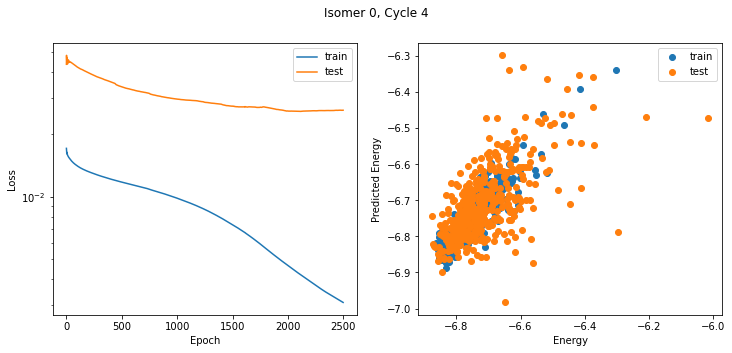

N_samples:  4000
N_samples*0.8:  3200
N_samples*0.2:  800
N iterations:  8000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  2500
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 7.90e-03 	 3.58e-02 	 3.6e-01
2.5e+02 	 5.00e-05 	 5.21e-03 	 3.03e-02 	 1.9e-01
5.0e+02 	 5.00e-05 	 4.27e-03 	 2.69e-02 	 1.6e-01
7.5e+02 	 5.00e-05 	 3.68e-03 	 2.50e-02 	 1.3e-01
1.0e+03 	 5.00e-05 	 3.21e-03 	 2.40e-02 	 1.1e-01
1.2e+03 	 5.00e-05 	 2.81e-03 	 2.34e-02 	 7.8e-02
1.5e+03 	 5.00e-05 	 2.51e-03 	 2.28e-02 	 6.6e-02
1.8e+03 	 5.00e-05 	 2.26e-03 	 2.22e-02 	 5.8e-02
2.0e+03 	 5.00e-05 	 2.04e-03 	 2.17e-02 	 5.1e-02
2.2e+03 	 5.00e-05 	 1.87e-03 	 2.12e-02 	 3.8e-02


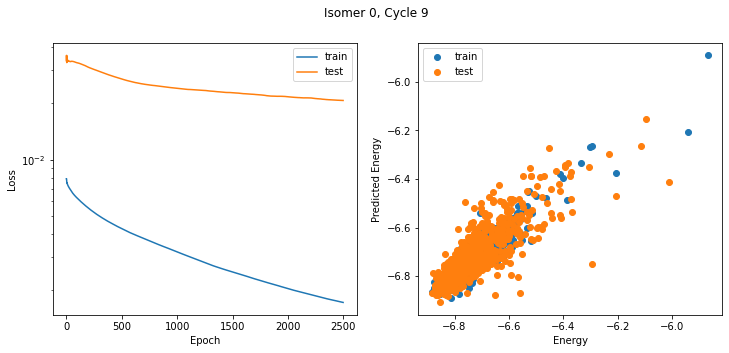

N_samples:  5500
N_samples*0.8:  4400
N_samples*0.2:  1100
N iterations:  14000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  3182
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 2.85e-03 	 2.25e-02 	 2.2e-01
3.2e+02 	 5.00e-05 	 2.08e-03 	 1.93e-02 	 2.2e-01
6.4e+02 	 5.00e-05 	 1.81e-03 	 1.81e-02 	 2.2e-01
9.5e+02 	 5.00e-05 	 1.62e-03 	 1.72e-02 	 2.2e-01
1.3e+03 	 5.00e-05 	 1.47e-03 	 1.66e-02 	 2.2e-01
1.6e+03 	 5.00e-05 	 1.35e-03 	 1.60e-02 	 2.2e-01
1.9e+03 	 5.00e-05 	 1.26e-03 	 1.55e-02 	 2.2e-01
2.2e+03 	 5.00e-05 	 1.17e-03 	 1.49e-02 	 2.2e-01
2.5e+03 	 5.00e-05 	 1.10e-03 	 1.44e-02 	 2.2e-01
2.9e+03 	 5.00e-05 	 1.04e-03 	 1.41e-02 	 2.2e-01
3.2e+03 	 5.00e-05 	 9.82e-04 	 1.39e-02 	 2.2e-01


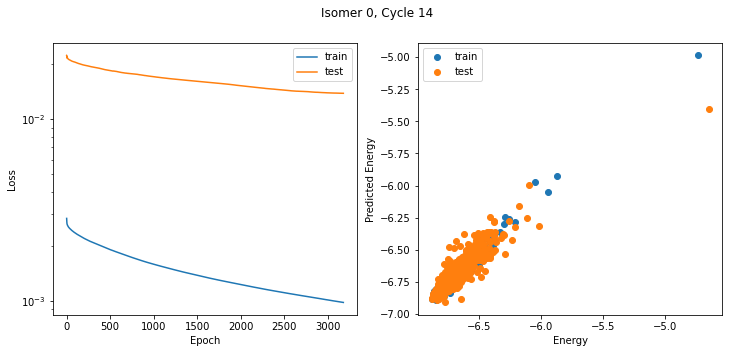

N_samples:  7000
N_samples*0.8:  5600
N_samples*0.2:  1400
N iterations:  23000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  4107
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 1.64e-03 	 1.39e-02 	 7.0e-01
4.1e+02 	 5.00e-05 	 9.30e-04 	 1.12e-02 	 7.0e-01
8.2e+02 	 5.00e-05 	 8.38e-04 	 1.07e-02 	 7.0e-01
1.2e+03 	 5.00e-05 	 7.76e-04 	 1.03e-02 	 7.0e-01
1.6e+03 	 5.00e-05 	 7.29e-04 	 1.01e-02 	 7.0e-01
2.0e+03 	 5.00e-05 	 6.94e-04 	 1.01e-02 	 7.0e-01
2.5e+03 	 5.00e-05 	 6.66e-04 	 1.01e-02 	 7.0e-01
2.9e+03 	 5.00e-05 	 6.35e-04 	 1.01e-02 	 7.0e-01
3.3e+03 	 5.00e-05 	 6.08e-04 	 1.01e-02 	 7.0e-01
3.7e+03 	 5.00e-05 	 5.84e-04 	 1.00e-02 	 7.0e-01
4.1e+03 	 5.00e-05 	 5.63e-04 	 9.96e-03 	 7.0e-01


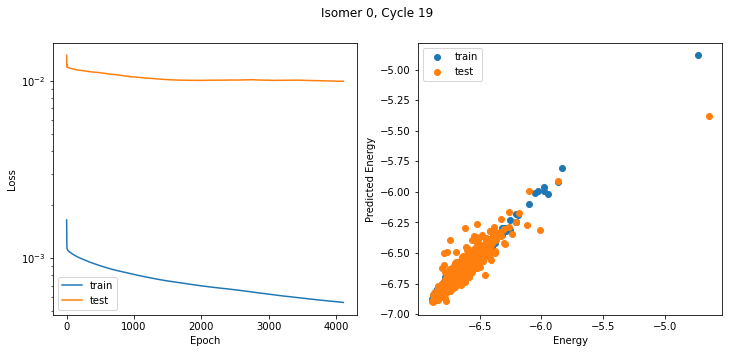

N_samples:  8500
N_samples*0.8:  6800
N_samples*0.2:  1700
N iterations:  35000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  5147
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 1.33e-03 	 9.31e-03 	 4.1e-01
5.1e+02 	 5.00e-05 	 6.95e-04 	 8.52e-03 	 4.1e-01
1.0e+03 	 5.00e-05 	 6.31e-04 	 8.48e-03 	 4.1e-01
1.5e+03 	 5.00e-05 	 5.86e-04 	 8.42e-03 	 4.1e-01
2.1e+03 	 5.00e-05 	 5.54e-04 	 8.49e-03 	 4.1e-01
2.6e+03 	 5.00e-05 	 5.20e-04 	 8.58e-03 	 4.1e-01
3.1e+03 	 5.00e-05 	 4.98e-04 	 8.55e-03 	 4.1e-01
3.6e+03 	 5.00e-05 	 4.80e-04 	 8.53e-03 	 4.1e-01
4.1e+03 	 5.00e-05 	 4.65e-04 	 8.46e-03 	 4.1e-01
4.6e+03 	 5.00e-05 	 4.52e-04 	 8.40e-03 	 4.1e-01
5.1e+03 	 5.00e-05 	 4.41e-04 	 8.37e-03 	 4.1e-01


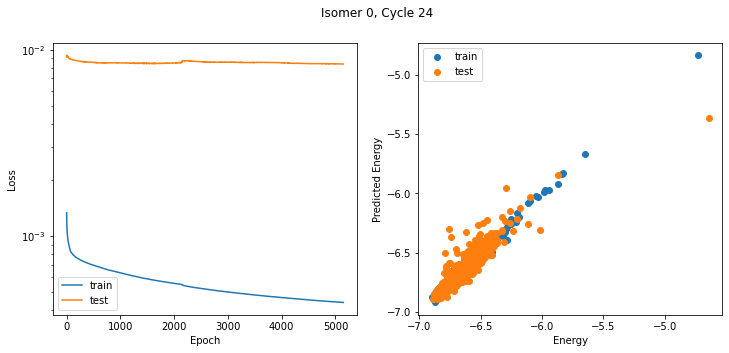

N_samples:  10000
N_samples*0.8:  8000
N_samples*0.2:  2000
N iterations:  50000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  6250
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 4.58e-03 	 1.01e-02 	 5.7e-02
6.2e+02 	 5.00e-05 	 6.50e-04 	 1.45e-02 	 5.9e-02
1.2e+03 	 5.00e-05 	 5.05e-04 	 1.17e-02 	 4.1e-02
1.9e+03 	 5.00e-05 	 4.48e-04 	 1.00e-02 	 3.7e-02
2.5e+03 	 5.00e-05 	 4.15e-04 	 8.94e-03 	 7.7e-02
3.1e+03 	 5.00e-05 	 3.93e-04 	 8.39e-03 	 5.7e-02
3.8e+03 	 5.00e-05 	 3.76e-04 	 7.91e-03 	 4.4e-02
4.4e+03 	 5.00e-05 	 3.62e-04 	 7.41e-03 	 4.3e-02
5.0e+03 	 5.00e-05 	 3.49e-04 	 7.04e-03 	 4.4e-02
5.6e+03 	 5.00e-05 	 3.40e-04 	 6.89e-03 	 4.9e-02


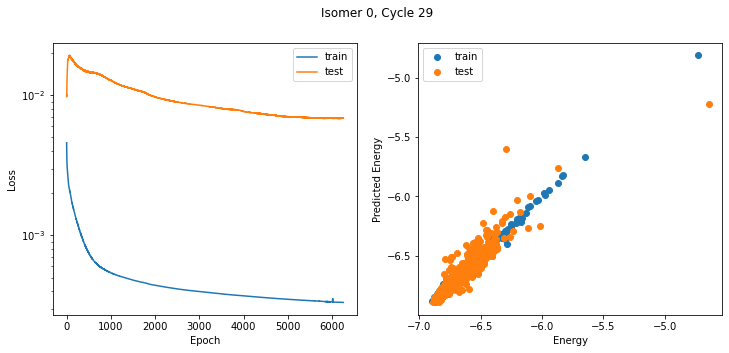

N_samples:  11500
N_samples*0.8:  9200
N_samples*0.2:  2300
N iterations:  68000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  7391
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 8.70e-04 	 9.11e-03 	 7.0e-01
7.4e+02 	 5.00e-05 	 3.82e-04 	 6.96e-03 	 7.0e-01
1.5e+03 	 5.00e-05 	 3.61e-04 	 6.89e-03 	 7.0e-01
2.2e+03 	 5.00e-05 	 3.49e-04 	 7.16e-03 	 7.0e-01
3.0e+03 	 5.00e-05 	 3.38e-04 	 7.29e-03 	 7.0e-01
3.7e+03 	 5.00e-05 	 3.27e-04 	 7.65e-03 	 7.0e-01
4.4e+03 	 5.00e-05 	 3.20e-04 	 7.66e-03 	 7.0e-01
5.2e+03 	 5.00e-05 	 3.13e-04 	 7.62e-03 	 7.0e-01
5.9e+03 	 5.00e-05 	 3.05e-04 	 7.40e-03 	 7.0e-01
6.7e+03 	 5.00e-05 	 3.01e-04 	 7.18e-03 	 7.0e-01
7.4e+03 	 5.00e-05 	 2.96e-04 	 6.96e-03 	 7.0e-01


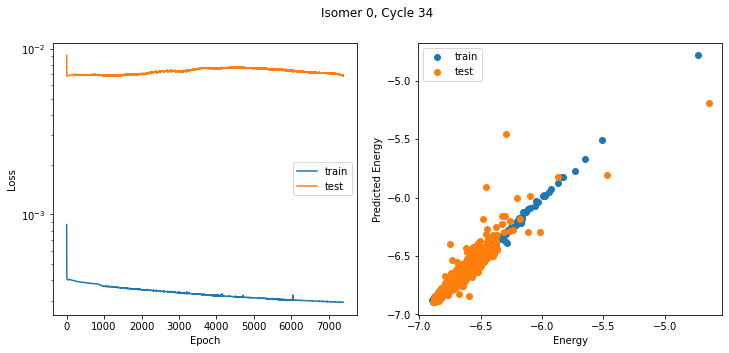

N_samples:  13000
N_samples*0.8:  10400
N_samples*0.2:  2600
N iterations:  89000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  8558
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 6.31e-04 	 7.19e-03 	 3.2e-01
8.6e+02 	 5.00e-05 	 3.23e-04 	 6.02e-03 	 3.2e-01
1.7e+03 	 5.00e-05 	 3.05e-04 	 5.64e-03 	 3.2e-01
2.6e+03 	 5.00e-05 	 2.96e-04 	 5.29e-03 	 3.2e-01
3.4e+03 	 5.00e-05 	 2.89e-04 	 5.09e-03 	 3.2e-01
4.3e+03 	 5.00e-05 	 2.83e-04 	 4.94e-03 	 3.2e-01
5.1e+03 	 5.00e-05 	 2.77e-04 	 4.75e-03 	 3.2e-01
6.0e+03 	 5.00e-05 	 2.72e-04 	 4.68e-03 	 3.2e-01
6.8e+03 	 5.00e-05 	 2.69e-04 	 4.64e-03 	 3.2e-01
7.7e+03 	 5.00e-05 	 2.64e-04 	 4.67e-03 	 3.2e-01
8.6e+03 	 5.00e-05 	 2.59e-04 	 4.75e-03 	 3.2e-01


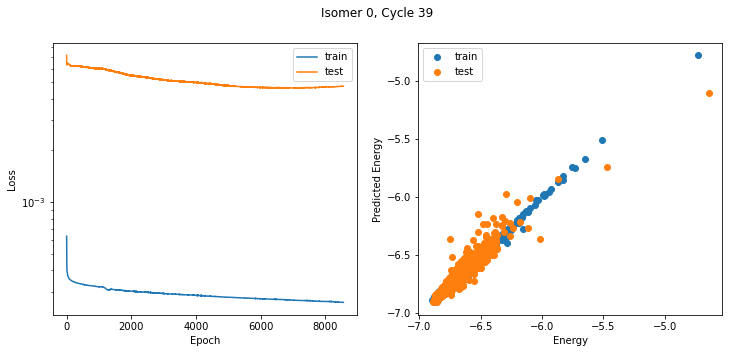

N_samples:  14500
N_samples*0.8:  11600
N_samples*0.2:  2900
N iterations:  113000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  9741
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 6.33e-04 	 6.45e-03 	 3.4e-01
9.7e+02 	 5.00e-05 	 2.55e-04 	 4.65e-03 	 3.4e-01
1.9e+03 	 5.00e-05 	 2.47e-04 	 4.45e-03 	 3.4e-01
2.9e+03 	 5.00e-05 	 2.41e-04 	 4.37e-03 	 3.4e-01
3.9e+03 	 5.00e-05 	 2.36e-04 	 4.32e-03 	 3.4e-01
4.9e+03 	 5.00e-05 	 2.31e-04 	 4.28e-03 	 3.4e-01
5.8e+03 	 5.00e-05 	 2.27e-04 	 4.24e-03 	 3.4e-01
6.8e+03 	 5.00e-05 	 2.22e-04 	 4.14e-03 	 3.4e-01
7.8e+03 	 5.00e-05 	 2.18e-04 	 4.07e-03 	 3.4e-01
8.8e+03 	 5.00e-05 	 2.14e-04 	 3.98e-03 	 3.4e-01
9.7e+03 	 5.00e-05 	 2.08e-04 	 3.80e-03 	 3.4e-01


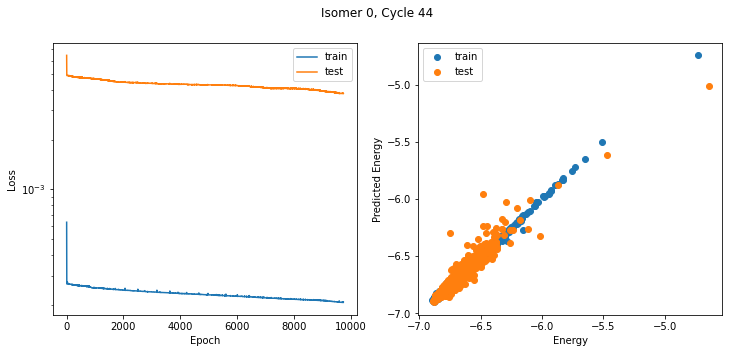

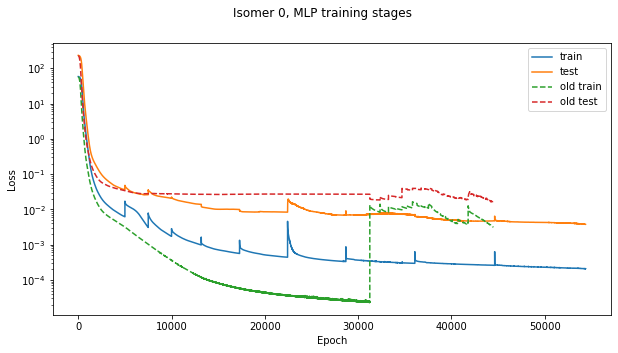

In [15]:
isomer = 0
idx = 31959910
hyperparams = {'dim': 12, 
'n_hidden': 64, 
'n_layers': 4, 
'n_iter': 5000, 
'lr': 5e-5, 
'bs': 1000,
'use_scheduler': False, 
'step_scheduler': 100, 
'with_tqdm': False}
init_n_samples = 1000
final_n_samples = 16000
step_n_samples = 300
skip = 5

models_is0, all_losses_is0 = run_training(isomer,
        idx,
        hyperparams,
        init_n_samples,
        final_n_samples,
        step_n_samples,
        skip)


N_samples:  1000
N_samples*0.8:  800
N_samples*0.2:  200
N iterations:  5000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  5000
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 5.33e+01 	 2.12e+02 	 1.6e+01
5.0e+02 	 5.00e-05 	 1.76e+01 	 6.86e+01 	 5.0e+01
1.0e+03 	 5.00e-05 	 3.10e-01 	 1.42e+00 	 9.4e-01
1.5e+03 	 5.00e-05 	 9.91e-02 	 4.65e-01 	 4.7e-01
2.0e+03 	 5.00e-05 	 2.25e-02 	 9.11e-02 	 1.9e-01
2.5e+03 	 5.00e-05 	 1.03e-02 	 3.35e-02 	 3.9e-02
3.0e+03 	 5.00e-05 	 7.75e-03 	 2.70e-02 	 1.9e-02
3.5e+03 	 5.00e-05 	 6.19e-03 	 2.44e-02 	 1.2e-02
4.0e+03 	 5.00e-05 	 5.05e-03 	 2.31e-02 	 9.0e-03
4.5e+03 	 5.00e-05 	 4.42e-03 	 2.19e-02 	 6.9e-03


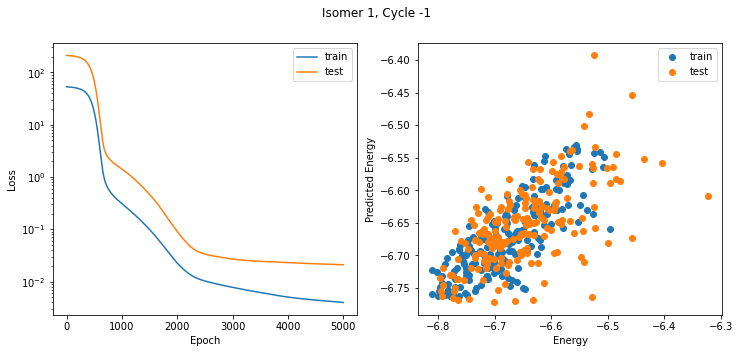

N_samples:  2500
N_samples*0.8:  2000
N_samples*0.2:  500
N iterations:  5000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  2500
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 5.27e-03 	 2.39e-02 	 4.0e-01
2.5e+02 	 5.00e-05 	 4.13e-03 	 2.17e-02 	 1.1e-02
5.0e+02 	 5.00e-05 	 3.59e-03 	 2.04e-02 	 1.9e-02
7.5e+02 	 5.00e-05 	 3.19e-03 	 1.96e-02 	 2.2e-02
1.0e+03 	 5.00e-05 	 2.86e-03 	 1.91e-02 	 2.9e-02
1.2e+03 	 5.00e-05 	 2.58e-03 	 1.87e-02 	 2.4e-02
1.5e+03 	 5.00e-05 	 2.33e-03 	 1.81e-02 	 2.4e-02
1.8e+03 	 5.00e-05 	 2.08e-03 	 1.74e-02 	 9.8e-03
2.0e+03 	 5.00e-05 	 1.83e-03 	 1.66e-02 	 8.8e-03
2.2e+03 	 5.00e-05 	 1.66e-03 	 1.59e-02 	 3.4e-02


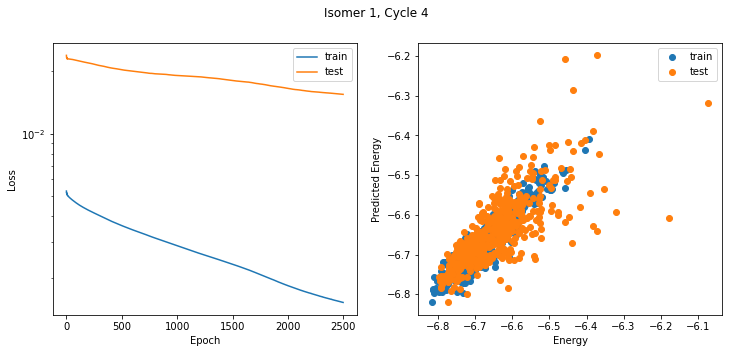

N_samples:  4000
N_samples*0.8:  3200
N_samples*0.2:  800
N iterations:  8000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  2500
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 6.24e-03 	 2.39e-02 	 8.3e-02
2.5e+02 	 5.00e-05 	 4.42e-03 	 2.21e-02 	 1.5e-01
5.0e+02 	 5.00e-05 	 3.69e-03 	 2.17e-02 	 1.2e-01
7.5e+02 	 5.00e-05 	 3.10e-03 	 2.10e-02 	 1.2e-01
1.0e+03 	 5.00e-05 	 2.60e-03 	 2.01e-02 	 1.1e-01
1.2e+03 	 5.00e-05 	 2.17e-03 	 1.88e-02 	 9.3e-02
1.5e+03 	 5.00e-05 	 1.78e-03 	 1.74e-02 	 7.6e-02
1.8e+03 	 5.00e-05 	 1.47e-03 	 1.62e-02 	 6.4e-02
2.0e+03 	 5.00e-05 	 1.26e-03 	 1.51e-02 	 4.2e-02
2.2e+03 	 5.00e-05 	 1.09e-03 	 1.43e-02 	 1.9e-02


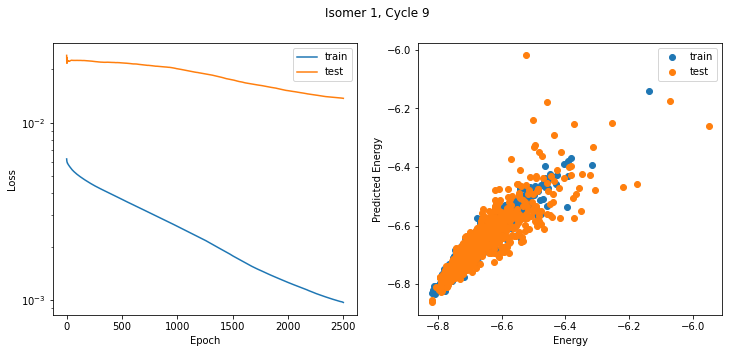

N_samples:  5500
N_samples*0.8:  4400
N_samples*0.2:  1100
N iterations:  14000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  3182
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 2.36e-03 	 1.33e-02 	 5.8e-01
3.2e+02 	 5.00e-05 	 1.45e-03 	 1.07e-02 	 5.8e-01
6.4e+02 	 5.00e-05 	 1.23e-03 	 9.97e-03 	 5.8e-01
9.5e+02 	 5.00e-05 	 1.08e-03 	 9.45e-03 	 5.8e-01
1.3e+03 	 5.00e-05 	 9.63e-04 	 9.35e-03 	 5.8e-01
1.6e+03 	 5.00e-05 	 8.85e-04 	 9.47e-03 	 5.8e-01
1.9e+03 	 5.00e-05 	 8.24e-04 	 9.55e-03 	 5.8e-01
2.2e+03 	 5.00e-05 	 7.75e-04 	 9.57e-03 	 5.8e-01
2.5e+03 	 5.00e-05 	 7.34e-04 	 9.47e-03 	 5.8e-01
2.9e+03 	 5.00e-05 	 6.94e-04 	 9.25e-03 	 5.8e-01
3.2e+03 	 5.00e-05 	 6.63e-04 	 9.17e-03 	 5.8e-01


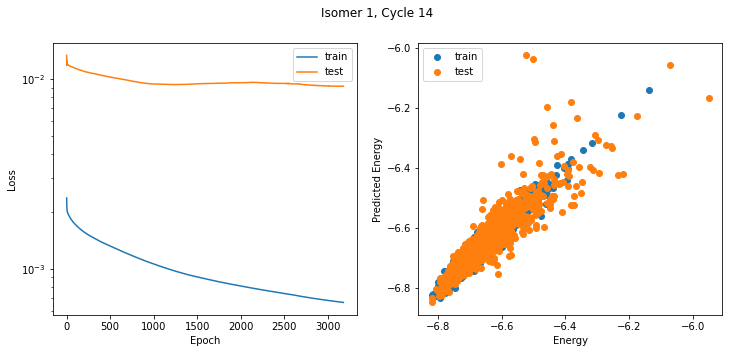

N_samples:  7000
N_samples*0.8:  5600
N_samples*0.2:  1400
N iterations:  23000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  4107
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 1.15e-03 	 1.18e-02 	 6.9e-01
4.1e+02 	 5.00e-05 	 6.75e-04 	 1.01e-02 	 6.9e-01
8.2e+02 	 5.00e-05 	 6.45e-04 	 1.00e-02 	 6.9e-01
1.2e+03 	 5.00e-05 	 6.12e-04 	 9.90e-03 	 6.9e-01
1.6e+03 	 5.00e-05 	 5.81e-04 	 9.59e-03 	 6.9e-01
2.0e+03 	 5.00e-05 	 5.50e-04 	 9.44e-03 	 6.9e-01
2.5e+03 	 5.00e-05 	 5.23e-04 	 9.07e-03 	 6.9e-01
2.9e+03 	 5.00e-05 	 5.00e-04 	 8.76e-03 	 6.9e-01
3.3e+03 	 5.00e-05 	 4.79e-04 	 8.44e-03 	 6.9e-01
3.7e+03 	 5.00e-05 	 4.63e-04 	 8.21e-03 	 6.9e-01
4.1e+03 	 5.00e-05 	 4.49e-04 	 8.02e-03 	 6.9e-01


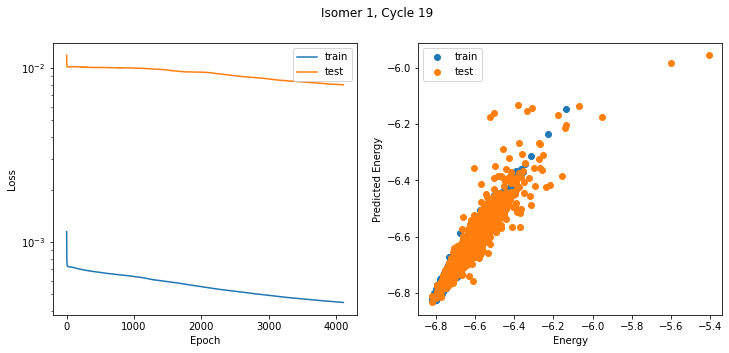

N_samples:  8500
N_samples*0.8:  6800
N_samples*0.2:  1700
N iterations:  35000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  5147
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 7.79e-04 	 8.15e-03 	 2.6e-01
5.1e+02 	 5.00e-05 	 4.46e-04 	 6.63e-03 	 2.6e-01
1.0e+03 	 5.00e-05 	 4.09e-04 	 6.34e-03 	 2.6e-01
1.5e+03 	 5.00e-05 	 3.91e-04 	 6.25e-03 	 2.6e-01
2.1e+03 	 5.00e-05 	 3.73e-04 	 6.09e-03 	 2.6e-01
2.6e+03 	 5.00e-05 	 3.57e-04 	 5.88e-03 	 2.6e-01
3.1e+03 	 5.00e-05 	 3.43e-04 	 5.77e-03 	 2.6e-01
3.6e+03 	 5.00e-05 	 3.29e-04 	 5.65e-03 	 2.6e-01
4.1e+03 	 5.00e-05 	 3.17e-04 	 5.53e-03 	 2.6e-01
4.6e+03 	 5.00e-05 	 3.06e-04 	 5.47e-03 	 2.6e-01
5.1e+03 	 5.00e-05 	 2.98e-04 	 5.38e-03 	 2.6e-01


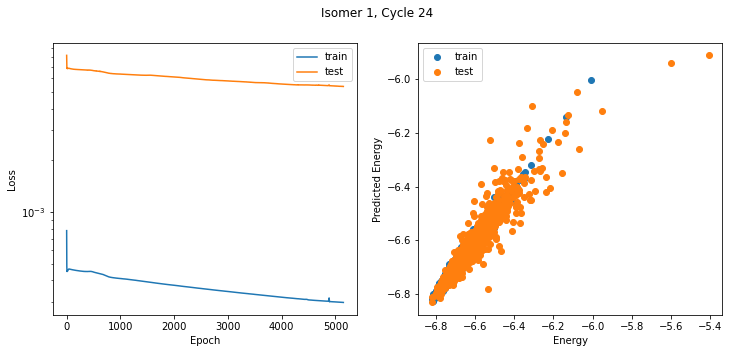

N_samples:  10000
N_samples*0.8:  8000
N_samples*0.2:  2000
N iterations:  50000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  6250
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 5.27e-04 	 5.75e-03 	 3.8e-01
6.2e+02 	 5.00e-05 	 2.84e-04 	 4.45e-03 	 1.7e-02
1.2e+03 	 5.00e-05 	 2.74e-04 	 4.42e-03 	 1.4e-02
1.9e+03 	 5.00e-05 	 2.64e-04 	 4.39e-03 	 8.8e-03
2.5e+03 	 5.00e-05 	 2.56e-04 	 4.37e-03 	 9.3e-03
3.1e+03 	 5.00e-05 	 2.47e-04 	 4.36e-03 	 5.9e-03
3.8e+03 	 5.00e-05 	 2.40e-04 	 4.31e-03 	 8.5e-03
4.4e+03 	 5.00e-05 	 2.33e-04 	 4.16e-03 	 1.3e-02
5.0e+03 	 5.00e-05 	 2.26e-04 	 4.04e-03 	 8.5e-03
5.6e+03 	 5.00e-05 	 2.20e-04 	 3.90e-03 	 1.5e-02


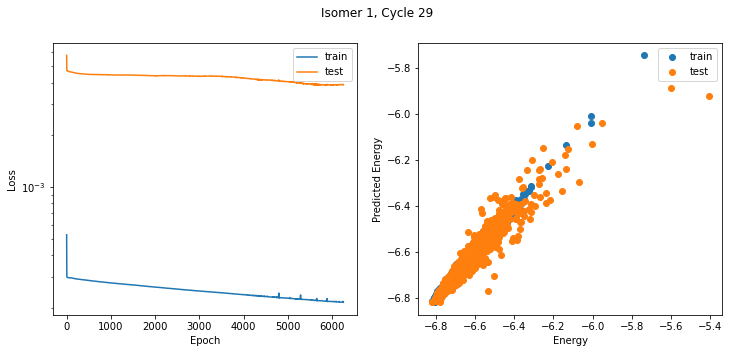

N_samples:  11500
N_samples*0.8:  9200
N_samples*0.2:  2300
N iterations:  68000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  7391
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 5.57e-04 	 5.13e-03 	 6.1e-01
7.4e+02 	 5.00e-05 	 2.31e-04 	 3.81e-03 	 6.1e-01
1.5e+03 	 5.00e-05 	 2.24e-04 	 3.79e-03 	 6.1e-01
2.2e+03 	 5.00e-05 	 2.19e-04 	 3.78e-03 	 6.1e-01
3.0e+03 	 5.00e-05 	 2.14e-04 	 3.77e-03 	 6.1e-01
3.7e+03 	 5.00e-05 	 2.13e-04 	 3.78e-03 	 6.1e-01
4.4e+03 	 5.00e-05 	 1.99e-04 	 3.73e-03 	 6.1e-01
5.2e+03 	 5.00e-05 	 1.95e-04 	 3.62e-03 	 6.1e-01
5.9e+03 	 5.00e-05 	 1.89e-04 	 3.57e-03 	 6.1e-01
6.7e+03 	 5.00e-05 	 1.85e-04 	 3.47e-03 	 6.1e-01
7.4e+03 	 5.00e-05 	 1.80e-04 	 3.37e-03 	 6.1e-01


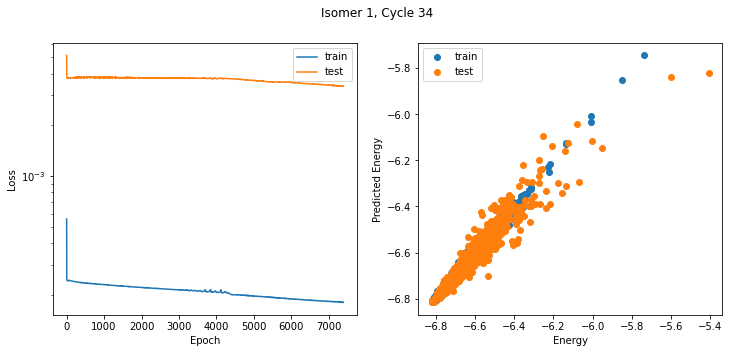

N_samples:  13000
N_samples*0.8:  10400
N_samples*0.2:  2600
N iterations:  89000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  8558
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 4.66e-04 	 4.14e-03 	 4.6e-01
8.6e+02 	 5.00e-05 	 1.80e-04 	 2.82e-03 	 4.6e-01
1.7e+03 	 5.00e-05 	 1.74e-04 	 2.74e-03 	 4.6e-01
2.6e+03 	 5.00e-05 	 1.68e-04 	 2.66e-03 	 4.6e-01
3.4e+03 	 5.00e-05 	 1.64e-04 	 2.58e-03 	 4.6e-01
4.3e+03 	 5.00e-05 	 1.60e-04 	 2.53e-03 	 4.6e-01
5.1e+03 	 5.00e-05 	 1.56e-04 	 2.45e-03 	 4.6e-01
6.0e+03 	 5.00e-05 	 1.53e-04 	 2.43e-03 	 4.6e-01
6.8e+03 	 5.00e-05 	 1.50e-04 	 2.42e-03 	 4.6e-01
7.7e+03 	 5.00e-05 	 1.47e-04 	 2.44e-03 	 4.6e-01
8.6e+03 	 5.00e-05 	 1.44e-04 	 2.48e-03 	 4.6e-01


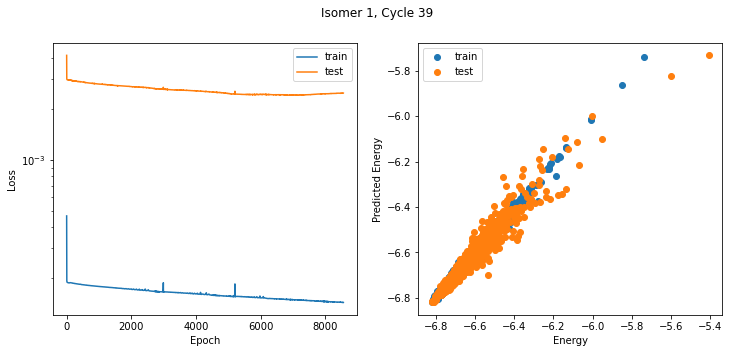

N_samples:  14500
N_samples*0.8:  11600
N_samples*0.2:  2900
N iterations:  113000
Batch size:  1000
Learning rate:  5e-05
Number of epochs:  9741
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 4.48e-04 	 3.45e-03 	 4.6e-01
9.7e+02 	 5.00e-05 	 1.43e-04 	 2.20e-03 	 4.6e-01
1.9e+03 	 5.00e-05 	 1.38e-04 	 2.12e-03 	 4.6e-01
2.9e+03 	 5.00e-05 	 1.35e-04 	 2.06e-03 	 4.6e-01
3.9e+03 	 5.00e-05 	 1.32e-04 	 2.04e-03 	 4.6e-01
4.9e+03 	 5.00e-05 	 1.31e-04 	 2.07e-03 	 4.6e-01
5.8e+03 	 5.00e-05 	 1.28e-04 	 2.11e-03 	 4.6e-01
6.8e+03 	 5.00e-05 	 1.26e-04 	 2.12e-03 	 4.6e-01
7.8e+03 	 5.00e-05 	 1.24e-04 	 2.11e-03 	 4.6e-01
8.8e+03 	 5.00e-05 	 1.22e-04 	 2.10e-03 	 4.6e-01
9.7e+03 	 5.00e-05 	 1.22e-04 	 2.11e-03 	 4.6e-01


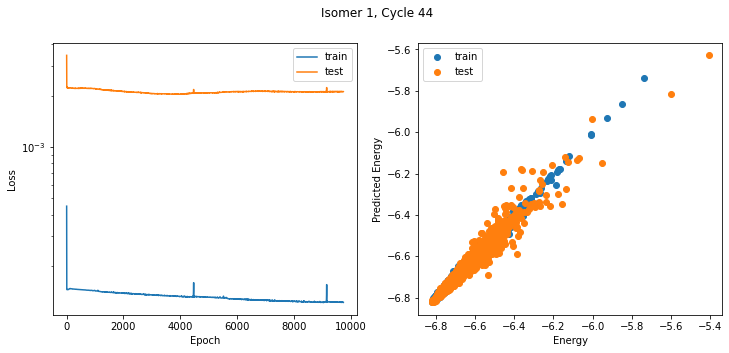

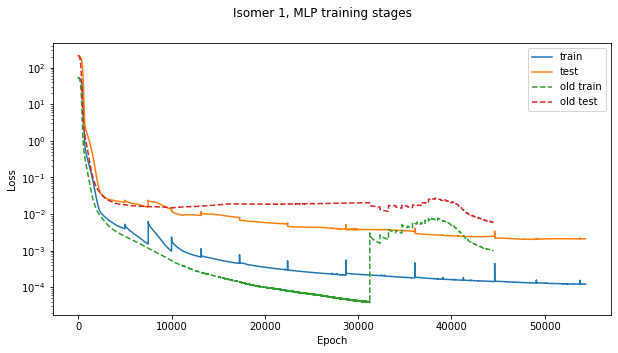

In [16]:
isomer = 1
idx = 31959913
#hyperparams = {'dim': 12, 
#'n_hidden': 64, 
#'n_layers': 4, 
#'n_iter': 25000, 
#'lr': 5e-5, 
#'bs': 5000, 
#'use_scheduler': False, 
#'step_scheduler': 100, 
#'with_tqdm': False}
#init_n_samples = 1000
#final_n_samples = 16000
#step_n_samples = 300
#skip = 5

models_is1, all_losses = run_training(isomer,
        idx,
        hyperparams,
        init_n_samples,
        final_n_samples,
        step_n_samples,
        skip)

N_samples:  1000
N_samples*0.8:  800
N_samples*0.2:  200
N iterations:  5000
Batch size:  5000
Learning rate:  5e-05
Number of epochs:  5000
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 2.74e+02 	 1.09e+03 	 1.6e+01
5.0e+02 	 5.00e-05 	 3.36e+01 	 1.28e+02 	 2.4e+01
1.0e+03 	 5.00e-05 	 3.21e+00 	 1.01e+01 	 2.7e+00
1.5e+03 	 5.00e-05 	 5.44e-01 	 2.16e+00 	 6.3e-01
2.0e+03 	 5.00e-05 	 2.12e-01 	 9.03e-01 	 2.3e-01
2.5e+03 	 5.00e-05 	 1.03e-01 	 4.41e-01 	 1.0e-01
3.0e+03 	 5.00e-05 	 6.72e-02 	 3.08e-01 	 5.2e-02
3.5e+03 	 5.00e-05 	 5.07e-02 	 2.48e-01 	 3.1e-02
4.0e+03 	 5.00e-05 	 4.20e-02 	 2.16e-01 	 2.1e-02
4.5e+03 	 5.00e-05 	 3.61e-02 	 1.96e-01 	 1.4e-02


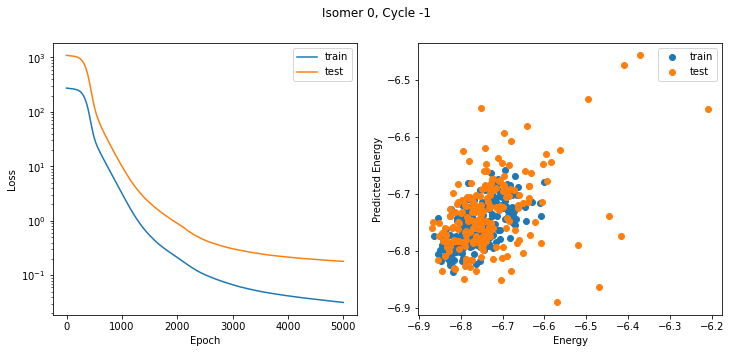

N_samples:  1600
N_samples*0.8:  1280
N_samples*0.2:  320
N iterations:  5000
Batch size:  5000
Learning rate:  5e-05
Number of epochs:  5000
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 5.72e-02 	 1.56e-01 	 5.3e-01
5.0e+02 	 5.00e-05 	 4.37e-02 	 1.35e-01 	 5.3e-03
1.0e+03 	 5.00e-05 	 3.86e-02 	 1.28e-01 	 4.9e-03
1.5e+03 	 5.00e-05 	 3.38e-02 	 1.26e-01 	 1.2e-02
2.0e+03 	 5.00e-05 	 2.96e-02 	 1.26e-01 	 8.0e-03
2.5e+03 	 5.00e-05 	 2.57e-02 	 1.25e-01 	 7.0e-03
3.0e+03 	 5.00e-05 	 2.12e-02 	 1.28e-01 	 5.0e-02
3.5e+03 	 5.00e-05 	 1.72e-02 	 1.22e-01 	 1.9e-02
4.0e+03 	 5.00e-05 	 1.41e-02 	 1.18e-01 	 3.6e-02
4.5e+03 	 5.00e-05 	 1.18e-02 	 1.17e-01 	 1.5e-02


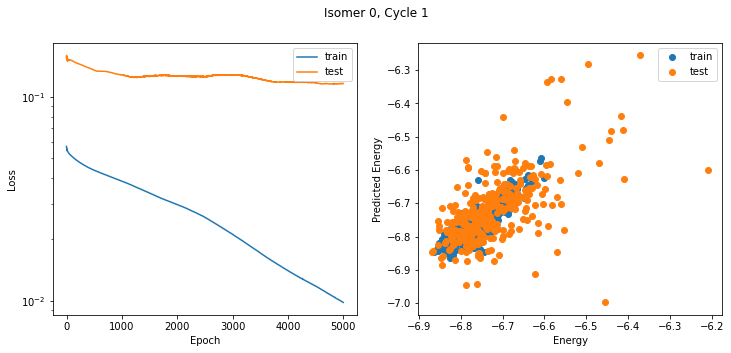

N_samples:  2200
N_samples*0.8:  1760
N_samples*0.2:  440
N iterations:  8000
Batch size:  5000
Learning rate:  5e-05
Number of epochs:  8000
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 1.29e-02 	 1.04e-01 	 2.4e-01
8.0e+02 	 5.00e-05 	 9.22e-03 	 8.93e-02 	 6.9e-03
1.6e+03 	 5.00e-05 	 7.19e-03 	 9.68e-02 	 2.8e-02
2.4e+03 	 5.00e-05 	 5.68e-03 	 1.00e-01 	 1.4e-02
3.2e+03 	 5.00e-05 	 4.68e-03 	 1.08e-01 	 1.6e-02
4.0e+03 	 5.00e-05 	 4.06e-03 	 1.14e-01 	 3.9e-02
4.8e+03 	 5.00e-05 	 3.54e-03 	 1.17e-01 	 4.2e-02
5.6e+03 	 5.00e-05 	 3.13e-03 	 1.18e-01 	 3.3e-02
6.4e+03 	 5.00e-05 	 2.80e-03 	 1.20e-01 	 1.7e-02
7.2e+03 	 5.00e-05 	 2.52e-03 	 1.22e-01 	 2.4e-02


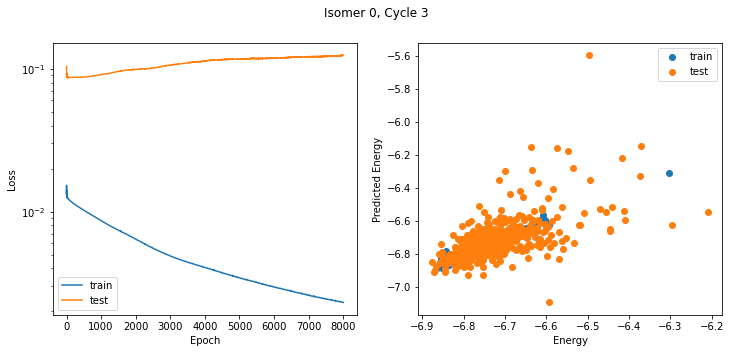

N_samples:  2800
N_samples*0.8:  2240
N_samples*0.2:  560
N iterations:  14000
Batch size:  5000
Learning rate:  5e-05
Number of epochs:  14000
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 5.40e-03 	 1.24e-01 	 1.8e-01
1.4e+03 	 5.00e-05 	 3.43e-03 	 9.50e-02 	 3.2e-03
2.8e+03 	 5.00e-05 	 2.66e-03 	 9.05e-02 	 5.0e-02
4.2e+03 	 5.00e-05 	 2.21e-03 	 8.75e-02 	 4.8e-02
5.6e+03 	 5.00e-05 	 1.95e-03 	 8.80e-02 	 5.4e-02
7.0e+03 	 5.00e-05 	 1.77e-03 	 8.73e-02 	 4.2e-02
8.4e+03 	 5.00e-05 	 1.63e-03 	 8.72e-02 	 5.4e-02
9.8e+03 	 5.00e-05 	 1.51e-03 	 8.55e-02 	 1.4e-02
1.1e+04 	 5.00e-05 	 1.40e-03 	 8.24e-02 	 1.3e-02
1.3e+04 	 5.00e-05 	 1.32e-03 	 8.17e-02 	 6.2e-02


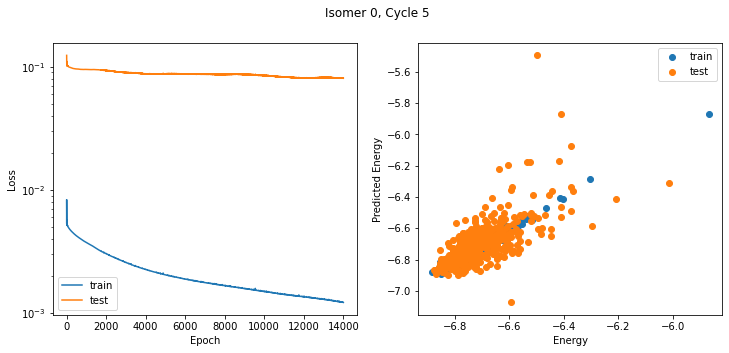

N_samples:  3400
N_samples*0.8:  2720
N_samples*0.2:  680
N iterations:  23000
Batch size:  5000
Learning rate:  5e-05
Number of epochs:  23000
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 3.52e-03 	 8.31e-02 	 1.5e-01
2.3e+03 	 5.00e-05 	 1.73e-03 	 5.28e-02 	 6.5e-02
4.6e+03 	 5.00e-05 	 1.36e-03 	 5.40e-02 	 1.3e-02
6.9e+03 	 5.00e-05 	 1.14e-03 	 5.52e-02 	 4.4e-03
9.2e+03 	 5.00e-05 	 1.00e-03 	 5.61e-02 	 2.7e-03
1.2e+04 	 5.00e-05 	 8.99e-04 	 5.82e-02 	 2.2e-02
1.4e+04 	 5.00e-05 	 8.21e-04 	 6.09e-02 	 1.0e-02
1.6e+04 	 5.00e-05 	 7.60e-04 	 6.23e-02 	 7.9e-03
1.8e+04 	 5.00e-05 	 7.12e-04 	 6.48e-02 	 1.0e-02
2.1e+04 	 5.00e-05 	 6.82e-04 	 6.57e-02 	 5.5e-02


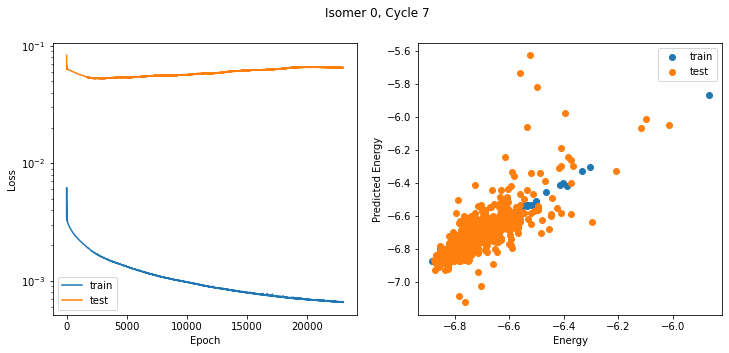

N_samples:  4000
N_samples*0.8:  3200
N_samples*0.2:  800
N iterations:  35000
Batch size:  5000
Learning rate:  5e-05
Number of epochs:  35000
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 2.27e-03 	 6.02e-02 	 9.0e-02
3.5e+03 	 5.00e-05 	 9.00e-04 	 4.50e-02 	 3.6e-02
7.0e+03 	 5.00e-05 	 7.62e-04 	 4.49e-02 	 1.8e-02
1.0e+04 	 5.00e-05 	 6.81e-04 	 4.53e-02 	 3.7e-02
1.4e+04 	 5.00e-05 	 6.25e-04 	 4.54e-02 	 3.3e-02
1.8e+04 	 5.00e-05 	 5.94e-04 	 4.46e-02 	 4.1e-02
2.1e+04 	 5.00e-05 	 5.71e-04 	 4.43e-02 	 3.4e-02
2.4e+04 	 5.00e-05 	 5.55e-04 	 4.39e-02 	 5.9e-02
2.8e+04 	 5.00e-05 	 5.38e-04 	 4.28e-02 	 6.5e-02
3.2e+04 	 5.00e-05 	 5.26e-04 	 4.24e-02 	 7.1e-02


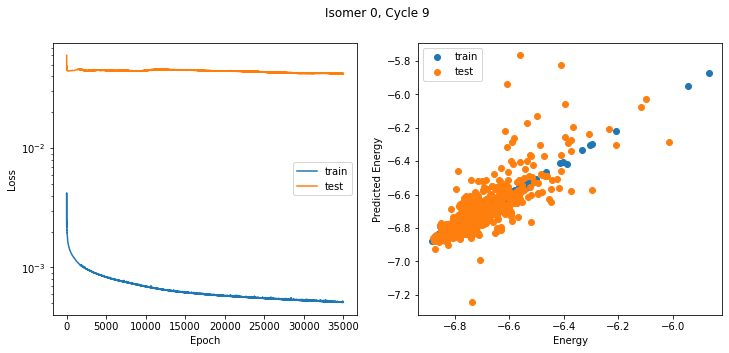

N_samples:  4600
N_samples*0.8:  3680
N_samples*0.2:  920
N iterations:  50000
Batch size:  5000
Learning rate:  5e-05
Number of epochs:  50000
Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm
0.0e+00 	 5.00e-05 	 1.32e-03 	 4.98e-02 	 7.7e-02
5.0e+03 	 5.00e-05 	 5.62e-04 	 3.54e-02 	 4.3e-02
1.0e+04 	 5.00e-05 	 4.93e-04 	 3.24e-02 	 2.4e-03


KeyboardInterrupt: 

In [17]:
isomer = 0
idx = 31959910
hyperparams = {'dim': 12, 
'n_hidden': 64, 
'n_layers': 4, 
'n_iter': 5000, 
'lr': 5e-5, 
'bs': 5000,
'use_scheduler': False, 
'step_scheduler': 100, 
'with_tqdm': False}
init_n_samples = 1000
final_n_samples = 16000
step_n_samples = 300
skip = 2

models_is0, all_losses_is0 = run_training(isomer,
        idx,
        hyperparams,
        init_n_samples,
        final_n_samples,
        step_n_samples,
        skip)